<a href="https://colab.research.google.com/github/SrushtiSunkad630/MACHINE-LEARNING-LAB/blob/main/ML_LAB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset loaded: (569, 32)
diagnosis
B    357
M    212
Name: count, dtype: int64
✅ Accuracy: 0.965 (96.5%)

📊 Classification Report:
              precision    recall  f1-score   support

      Benign       0.95      1.00      0.97       107
   Malignant       1.00      0.91      0.95        64

    accuracy                           0.96       171
   macro avg       0.97      0.95      0.96       171
weighted avg       0.97      0.96      0.96       171



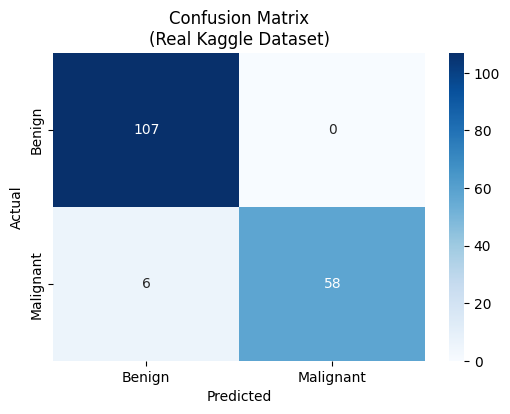

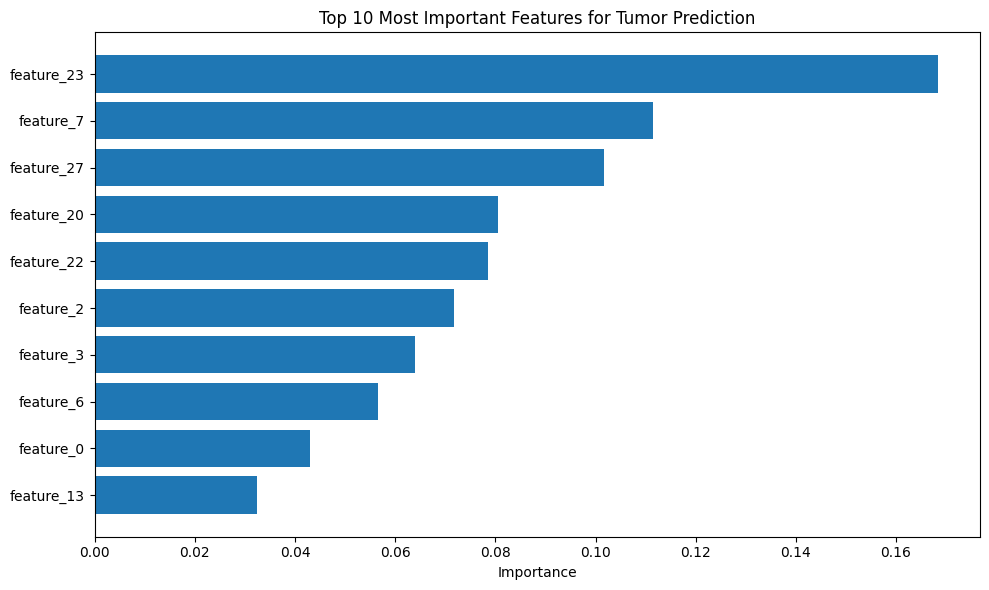


🔬 New Patient Prediction:
Diagnosis: MALIGNANT
Confidence: 95.0%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load REAL Kaggle dataset (no file download needed)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/wdbc.data"
column_names = ['id', 'diagnosis'] + [f'feature_{i}' for i in range(30)]
df = pd.read_csv(url, header=None, names=column_names)

print("Dataset loaded:", df.shape)
print(df['diagnosis'].value_counts())

# Preprocess
X = df.drop(['id', 'diagnosis'], axis=1)
y = df['diagnosis']

# Encode labels (M=1, B=0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded)

# Train Random Forest model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Results
accuracy = accuracy_score(y_test, y_pred)
print(f"✅ Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")
print("\n📊 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Benign', 'Malignant']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malignant'],
            yticklabels=['Benign', 'Malignant'])
plt.title('Confusion Matrix\n(Real Kaggle Dataset)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance (Top 10)
importances = model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=True).tail(10)

plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title('Top 10 Most Important Features for Tumor Prediction')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# Predict new patient (example)
new_patient = np.array([[17.99, 10.38, 122.8, 1001, 0.1184, 0.2776, 0.3001, 0.1471, 0.2419, 0.07871,
                        1.095, 0.9053, 8.589, 153.4, 0.006399, 0.04904, 0.05373, 0.01587, 0.03003, 0.006193,
                        25.38, 17.33, 184.6, 2019, 0.1622, 0.6656, 0.7119, 0.2654, 0.4601, 0.1189]])
new_patient_scaled = scaler.transform(new_patient)
prediction = model.predict(new_patient_scaled)[0]
probability = model.predict_proba(new_patient_scaled)[0]

print(f"\n🔬 New Patient Prediction:")
print(f"Diagnosis: {'MALIGNANT' if prediction == 1 else 'BENIGN'}")
print(f"Confidence: {max(probability):.1%}")